# Table of Contents

1. [Project Overview](#Project-Overview)
2. [Dataset](#dataset)
3. [Model Architecture (From Scratch)](#Model-Architecture-From-Scratch)
4. [Baseline Implementation](#Baseline-Implementation)
5. [Optimization Techniques](#Optimization-Techniques)
6. [Evaluation Metrics](#Evaluation-Metrics)
7. [Ablation Study](#Ablation-Study)
    - [Learning Rate Comparisons](#Learning-Rate-Comparisons)
    - [Regularization](#Regularization)
        - [Effect of Dropout Probability](#Effect-of-Dropout-Probability)
        - [Effect of L2 Regularization Strength](#Effect-of-L2-Regularization-Strength)
    - [Effect of Optimization Algorithm](#Effect-of-Optimization-Algorithm)
    - [Effect of Adam Hyperparameters](#Effect-of-Adam-Hyperparameters)
8. [Final Model Configuration](#Final-Model-Configuration)
9. [Results and Discussion](#Results-and-Discussion)
10. [Conclusion](#Conclusion)

## Project Overview

This project implements a neural network from scratch to classify CIFAR-10 images.  
The objective is to achieve at least 75% test accuracy.  

An ablation study is conducted to evaluate:
- Learning rate decay strategies  
- Regularization methods (L2, Dropout)  
- Optimization algorithms (SGD, Momentum, Adam)  
- Adam hyperparameter sensitivity  

## Dataset

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from util import get_device
from evaluations import train_model, plot_metrics
from model.model import Model

In [3]:
# CIFAR-10 normalization stats
cifar_mean = [0.485, 0.456, 0.406]
cifar_std  = [0.229, 0.224, 0.225]


# Training transforms (with augmentation + normalization)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


# Test transforms (NO augmentation, but WITH normalization)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_transform
)


from torch.utils.data import DataLoader
batch_size = 128
train_loader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

c:\Users\alexm\Documents\GitHub\CIFAR-10-Image-Classifier\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Data Format & Batch Creation

In [ ]:
image, label = training_data[0]
print("Image Shape: ", image.shape)
print("Label: ", label)

print("All Class Labels: \n", training_data.classes)

for images, labels in train_loader:
    print("images: [batch_size, channels, height, width]")
    print(images.shape)
    print("labels: [batch_size]")
    print(labels.shape)

    break


torch.Size([3, 32, 32])
Label:  6
All Class Labels: 
 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
images: [batch_size, channels, height, width]
torch.Size([128, 3, 32, 32])
labels: [batch_size]
torch.Size([128])


# Example images

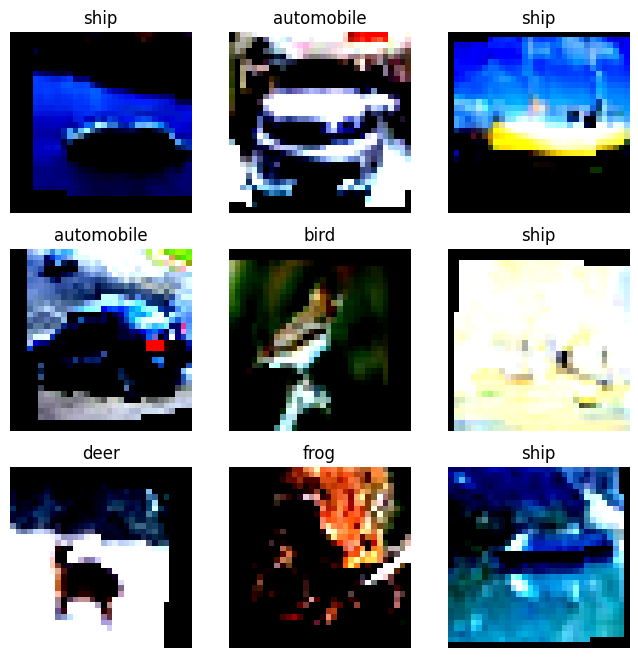

In [6]:
from util import show_random_images
show_random_images(training_data)


## Create model (Pytorch Implementation)

### Layer Creation

In [4]:
device = get_device()

NVIDIA CUDA detected
Set to use device: cuda


In [ ]:
main_model = Model()
train_model(
    model=main_model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=50,
    lr=0.001,
    optimizer_type="adam",
    weight_decay=1e-4,
    learn_rate_type="cosine",
    gamma=0.9
)
print() 

Epoch 1: Loss 1.5285, Train 44.01%, Test 55.02%
Epoch 2: Loss 1.2404, Train 55.14%, Test 61.92%
Epoch 3: Loss 1.1383, Train 59.33%, Test 65.04%
Epoch 4: Loss 1.0672, Train 61.70%, Test 65.40%
Epoch 5: Loss 1.0123, Train 63.92%, Test 69.38%
Epoch 6: Loss 0.9651, Train 65.67%, Test 70.82%
Epoch 7: Loss 0.9334, Train 67.08%, Test 70.72%
Epoch 8: Loss 0.9084, Train 67.74%, Test 71.75%
Epoch 9: Loss 0.8759, Train 69.02%, Test 69.94%
Epoch 10: Loss 0.8535, Train 70.01%, Test 72.73%
Epoch 11: Loss 0.8320, Train 70.83%, Test 73.77%
Epoch 12: Loss 0.8163, Train 71.27%, Test 73.22%
Epoch 13: Loss 0.7927, Train 72.19%, Test 74.36%
Epoch 14: Loss 0.7773, Train 72.62%, Test 74.27%
Epoch 15: Loss 0.7569, Train 73.07%, Test 75.48%
Epoch 16: Loss 0.7436, Train 74.07%, Test 75.26%
Epoch 17: Loss 0.7314, Train 74.37%, Test 75.84%
Epoch 18: Loss 0.7154, Train 74.74%, Test 76.34%
Epoch 19: Loss 0.7001, Train 75.34%, Test 77.39%
Epoch 20: Loss 0.6926, Train 75.66%, Test 77.08%
Epoch 21: Loss 0.6821, Train 

In [ ]:
# torch.save(main_model.state_dict(), "cifar10_model_main.pth")

# Abalation Study

## Base Model

Epoch 1: Loss 1.6414, Train 39.47%, Test 51.15%
Epoch 2: Loss 1.3426, Train 50.85%, Test 57.34%
Epoch 3: Loss 1.2050, Train 56.41%, Test 62.11%
Epoch 4: Loss 1.1141, Train 60.04%, Test 63.94%
Epoch 5: Loss 1.0504, Train 62.56%, Test 65.14%


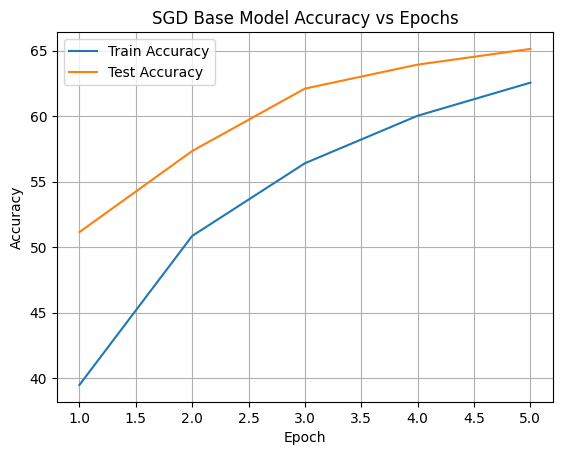

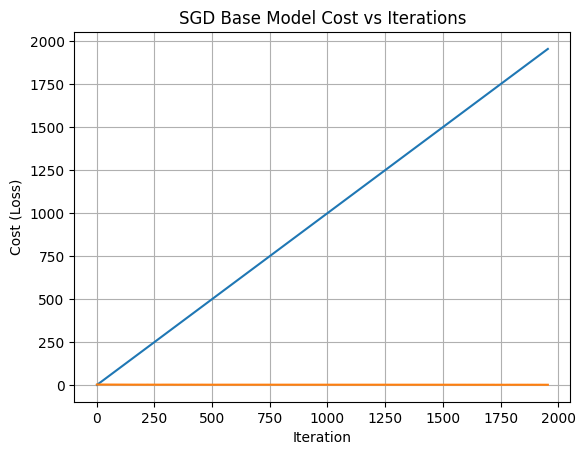

In [5]:
base_model, base_train_accs, base_test_accs, base_train_costs = train_model(
    model=Model(),
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=5,
    lr=0.01,
    optimizer_type="sgd",
    weight_decay=0.0,
    learn_rate_type=None
)

plot_metrics(
    train_accs=base_train_accs,
    test_accs=base_test_accs,
    costs=base_train_costs,
    title_prefix="SGD Base Model"
)

## Regularization

### L2 Regularization 

Epoch 1: Loss 1.6559, Train 38.81%, Test 52.98%
Epoch 2: Loss 1.3533, Train 50.71%, Test 58.61%
Epoch 3: Loss 1.2169, Train 55.73%, Test 62.69%
Epoch 4: Loss 1.1322, Train 59.13%, Test 65.42%
Epoch 5: Loss 1.0646, Train 61.96%, Test 67.33%
Epoch 1: Loss 1.6476, Train 39.12%, Test 48.83%
Epoch 2: Loss 1.3469, Train 50.83%, Test 58.77%
Epoch 3: Loss 1.2210, Train 55.71%, Test 63.37%
Epoch 4: Loss 1.1243, Train 59.66%, Test 64.47%
Epoch 5: Loss 1.0622, Train 61.94%, Test 67.27%
Epoch 1: Loss 1.6359, Train 39.62%, Test 52.02%
Epoch 2: Loss 1.3415, Train 51.38%, Test 57.87%
Epoch 3: Loss 1.2156, Train 56.14%, Test 62.46%
Epoch 4: Loss 1.1270, Train 59.51%, Test 65.02%
Epoch 5: Loss 1.0619, Train 62.14%, Test 65.54%
Epoch 1: Loss 1.6337, Train 39.95%, Test 52.38%
Epoch 2: Loss 1.3322, Train 51.20%, Test 58.42%
Epoch 3: Loss 1.2129, Train 56.19%, Test 62.97%
Epoch 4: Loss 1.1209, Train 59.95%, Test 65.22%
Epoch 5: Loss 1.0554, Train 62.46%, Test 67.24%
Epoch 1: Loss 1.6341, Train 39.70%, Test

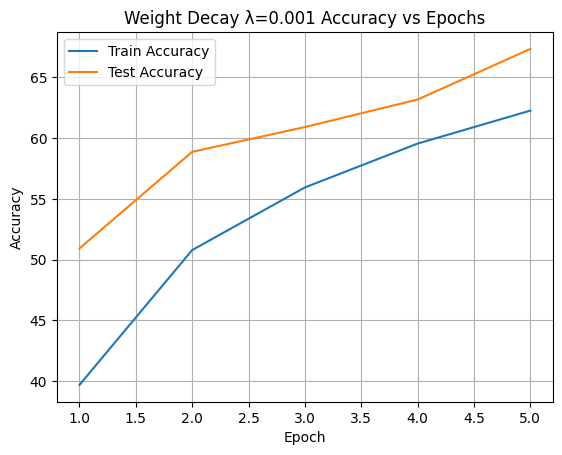

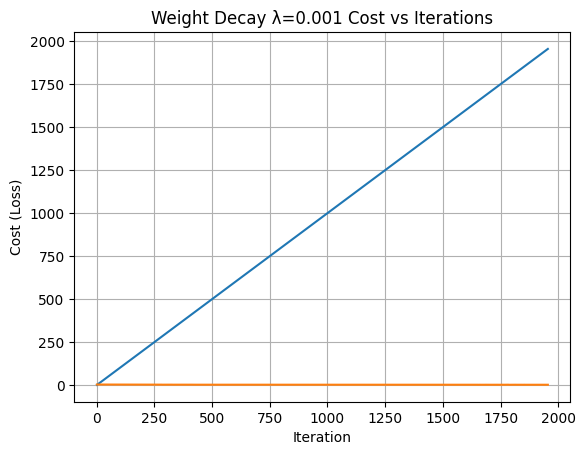

In [6]:
test_lambdas = [0, 1e-5, 1e-4, 5e-4, 1e-3]
models = {}
for i in range(len(test_lambdas)):
  lam = test_lambdas[i]
  model, train_accs, test_accs, train_costs = train_model(
      model=Model(),
      train_loader=train_loader,
      test_loader=test_loader,
      device=device,
      epochs=5,
      lr=0.01,
      optimizer_type="sgd",
      weight_decay=lam
  )
  models[lam] = {
      "model": model,
      "train_accs": train_accs,
      "test_accs": test_accs,
      "train_costs": train_costs
  }
plot_metrics(
    train_accs=train_accs,
    test_accs=test_accs,
    costs=train_costs,
    title_prefix=f"Weight Decay λ={lam}"
)

### Dropout (P = .3, .5, .7)

In [ ]:
test_p = [0, .3, .5, .7]
models = {}
for i in range(len(test_p)):
  p = test_p[i]
  model, train_accs, test_accs, train_costs = train_model(
      model=Model(dropout_p=p),
      train_loader=train_loader,
      test_loader=test_loader,
      device=device,
      epochs=5,
      lr=0.01,
      optimizer_type="sgd",
      weight_decay=0
  )
  models[p] = {
      "model": model,
      "train_accs": train_accs,
      "test_accs": test_accs,
      "train_costs": train_costs
  }

plot_metrics(
    train_accs=train_accs,
    test_accs=test_accs,
    costs=train_costs,
    title_prefix=f"Dropout p={p}"
)

## Optimization Algorithms

### Cosine Decay

In [ ]:
test_betas = [(0.9, 0.999), (0.8, 0.99), (0.7, 0.9)]

models = {}

for beta in test_betas:
    model, train_accs, test_accs, train_costs = train_model(
        model=Model(),
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        epochs=5,
        lr=0.01,
        optimizer_type="cosine",
        betas=beta,
        weight_decay=0
    )

    models[beta] = {
        "model": model,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "train_costs": train_costs
    }

plt.figure()

for beta, data in models.items():
    epochs = range(1, len(data["train_accs"]) + 1)
    
    plt.plot(epochs, data["test_accs"], label=f"{beta} (test)")
    plt.plot(epochs, data["train_accs"], linestyle='--', label=f"{beta} (train)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Optimizer Betas Comparison (Train vs Test)")
plt.legend()
plt.show()
plt.figure()

for beta, data in models.items():
    plt.plot(data["train_costs"], label=f"{beta}")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss for Different Betas")
plt.legend()
plt.show()

### Adam - Beta1 & Beta2

Epoch 1: Loss 2.1968, Train 17.21%, Test 18.45%
Epoch 2: Loss 1.9242, Train 19.56%, Test 20.42%
Epoch 3: Loss 1.8716, Train 21.15%, Test 21.16%
Epoch 4: Loss 1.7717, Train 27.45%, Test 34.35%
Epoch 5: Loss 1.6029, Train 36.21%, Test 40.38%
Epoch 1: Loss 2.4248, Train 10.00%, Test 10.00%
Epoch 2: Loss 2.3033, Train 9.88%, Test 10.00%
Epoch 3: Loss 2.3034, Train 9.89%, Test 10.00%
Epoch 4: Loss 2.3033, Train 9.80%, Test 10.00%
Epoch 5: Loss 2.3033, Train 10.18%, Test 10.00%
Epoch 1: Loss 1.9032, Train 31.56%, Test 40.73%
Epoch 2: Loss 1.4812, Train 43.45%, Test 47.10%
Epoch 3: Loss 1.3449, Train 49.38%, Test 55.13%
Epoch 4: Loss 1.2765, Train 52.65%, Test 53.72%
Epoch 5: Loss 1.2373, Train 54.27%, Test 57.55%


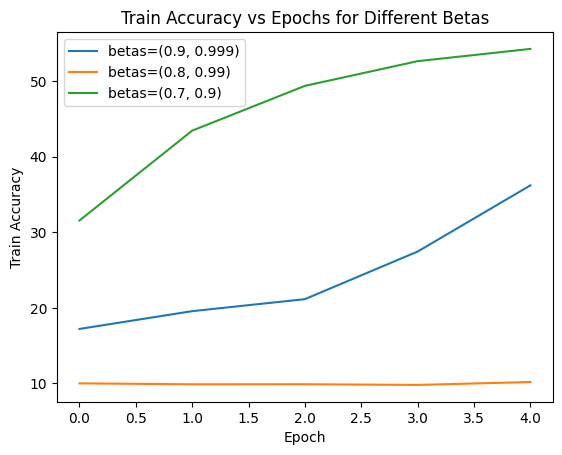

In [ ]:
test_betas = [(0.9, 0.999), (0.8, 0.99), (0.7, 0.9)]

models = {}

for beta in test_betas:
  model, train_accs, test_accs, train_costs = train_model(
    model=Model(),
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=5,
    lr=0.01,
    optimizer_type="adam",
    betas=beta,
    weight_decay=0
  )

  models[beta] = {
    "model": model,
    "train_accs": train_accs,
    "test_accs": test_accs,
    "train_costs": train_costs
  }

plt.figure()

for beta in test_betas:
    plt.plot(models[beta]["train_accs"], label=f"betas={beta}")

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy")
plt.title("Train Accuracy vs Epochs for Different Betas")
plt.legend()
plt.show()